In [1]:
import numpy as np
from typing import List, Dict, Tuple, Union
from numpy.typing import ArrayLike
import random
from nn.nn import NeuralNetwork
from nn.io import read_text_file, read_fasta_file
from nn.preprocess import sample_seqs, one_hot_encode_seqs
from sklearn.model_selection import train_test_split
import sklearn
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [2]:
# Set seed for all models!
seed_to_use = 42

## Autoencoder

In [3]:
# load dataset using sklearn
dataset = sklearn.datasets.load_digits()
n_samples = len(dataset.images)
X = dataset.images.reshape((n_samples, -1)) / 16 # extract feats
y = dataset.target # extract target labels (numbers)

# split data into 80/20 train/val split
X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.2,random_state=seed_to_use)

In [12]:
# define neural network
# NOTE: I used relu as activation function for hidden layer since it worked best from prior experience
autoencoder_arch = [
    {'input_dim': 64, 'output_dim': 16, 'activation': 'relu'},
    {'input_dim': 16, 'output_dim': 64, 'activation': 'sigmoid'},
]
# define parameters
lr=1e-2 # learning rate
batch_size = 64 # batch size
epochs = 250 # number of epochs (how many times the network would see the data)
loss_func = 'mean_squared_error' # using MSE since target is not binary/classification
# create autoencoder with Neural Network class with specified parameters
autoencoder = NeuralNetwork(nn_arch=autoencoder_arch, lr=lr, batch_size=batch_size, epochs=epochs,
                            loss_function=loss_func, seed=seed_to_use)
# return train and val losses
autoencoder_losses = autoencoder.fit(X_train, X_train, X_val, X_val)

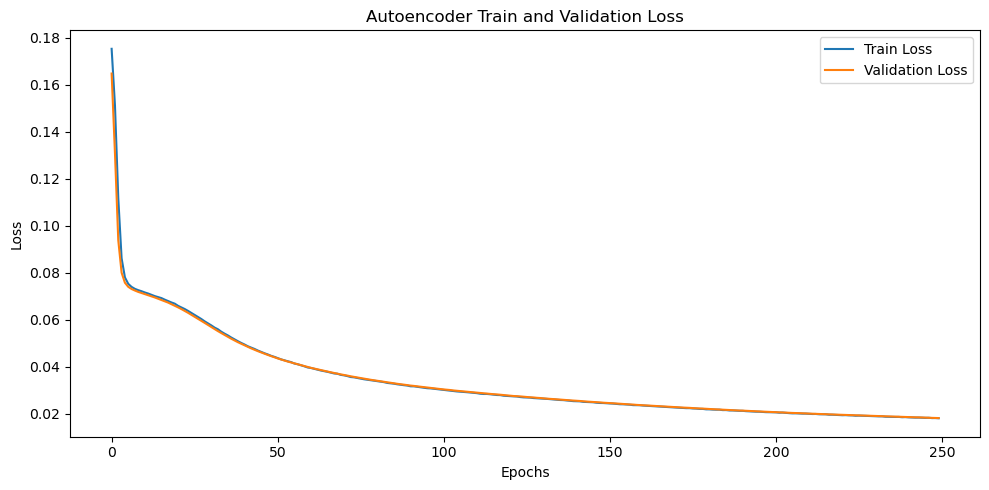

In [13]:
# Plot losses
plt.figure(figsize=(10,5))
plt.plot(autoencoder_losses[0], label='Train Loss')
plt.plot(autoencoder_losses[1], label='Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend()

plt.title('Autoencoder Train and Validation Loss')
plt.tight_layout()
plt.show()

Autoencoder reconstruction loss on validation: 0.018163
Autoencoder reconstruction loss on train: 0.018030


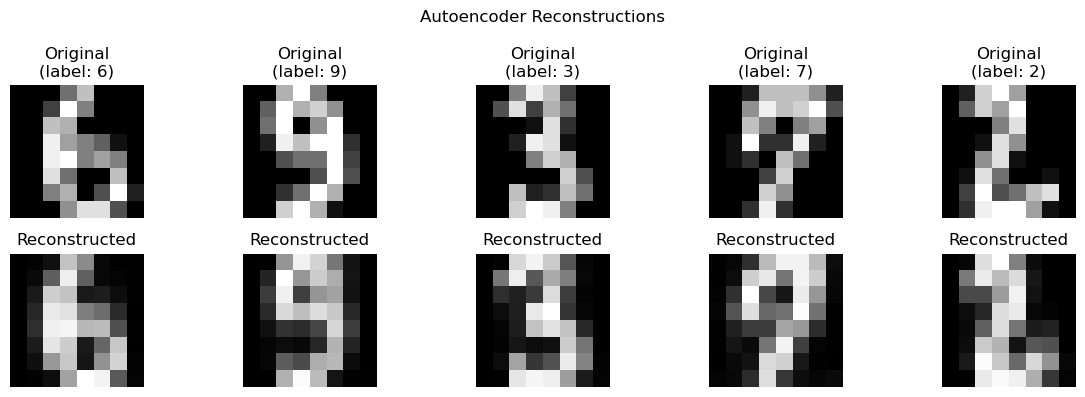

In [14]:
n_examples = 5
X_reconstructed = autoencoder.predict(X_val)
reconstruction_loss = np.mean((X_val - X_reconstructed)**2)
reconstruction_loss_train = np.mean((X_train - autoencoder.predict(X_train))**2)
print(f'Autoencoder reconstruction loss on validation: {reconstruction_loss:4f}')
print(f'Autoencoder reconstruction loss on train: {reconstruction_loss_train:4f}')

fig, axes = plt.subplots(2, n_examples, figsize=(12, 4))

for i in range(n_examples):
    # original
    axes[0, i].imshow(X_val[i].reshape(8, 8), cmap='gray')
    axes[0, i].set_title(f'Original\n(label: {y_val[i]})')
    axes[0, i].axis('off')
    
    # reconstruction
    axes[1, i].imshow(X_reconstructed[i].reshape(8, 8), cmap='gray')
    axes[1, i].set_title('Reconstructed')
    axes[1, i].axis('off')

plt.suptitle('Autoencoder Reconstructions')
plt.tight_layout()
plt.show()

### Autoencoder Params Explanation

For the autoencoder, I used the following params:
- **encoder activation function**: ReLU(). This function works better than sigmoid for the encoder layer since it does not suffer from vanishing gradient issues that are common with sigmoid. Additionally, from my previous experience with autoencoders, ReLU() is a faster and more optimal choice for this particular layer.
- **decoder activation function**: Sigmoid(). The decoder's output layer is the output layer for the autoencoder. As such, the sigmoid activation function works well here since it returns values in the range [0,1], which is the exact range of our pixel values after normalization. ReLU() would have returned weights incompatible with our output and that would otherwise have been harder to work with.
- **loss function**: MSE. Since we want to replicate/reconstruct images, we want to measure deviation from true to predicted pixel values. Therefore, MSE is much better suited for this as it is unbiased and works better than BCE, which expects binary loss.
- **learning rate**: lr of 0.01 was used. This was found through trial error: lr of 1e-3 or lower gave suboptimal results where as lr of 1e-1 similarly gave unstable outputs. lr of 0.01 works the best for this particular architecture, providing a good balance between speed of learning and reasonable reconstruction.
- **batch size**: A batch size of 8 was used. Larger batch size amounts led to faster training, but poorer performance. Batch sizes smaller than 8 took much longer and did not yield meaningful gains in performance. Therefore, a batch size of 8 was chosen.
- **epochs**: The model was trained for 250 epochs. This was also found through trial and error: a fewer epoch count returned loss curves that indicated the model could still "learn more" whereas a larger epoch count (500+) took very long and did not yield a significant gain in performance. An epoch count of 250 was a good balance between the two: large enough to offer good performance, but small enough to take only a few seconds to train.

## Classifier

In [20]:
# load positive and negative samples
positive_ex = read_text_file('./data/rap1-lieb-positives.txt')
pos_labels = [1 for _ in range(len(positive_ex))]
negative_ex_raw = read_fasta_file('./data/yeast-upstream-1k-negative.fa')

# make negative labels equal
seq_len = 17 # length of positive sequences
negative_ex = []
for seq in negative_ex_raw:
    for i in range(0, len(seq) - seq_len+1, seq_len):
        negative_ex.append(seq[i:i+seq_len])

neg_labels = [0 for _ in range(len(negative_ex))]

# aggregate
all_labels = pos_labels+neg_labels
all_seqs = positive_ex+negative_ex
# first split before balancing to prevent leakage
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(all_seqs, all_labels, test_size=0.2,
                                                          random_state=seed_to_use)

sampled_seqs, sampled_labels = sample_seqs(X_train_raw, y_train_raw)
# First one-hot encode before splitting (to prevent leakage)
encodings_train = one_hot_encode_seqs(sampled_seqs)
encodings_val = one_hot_encode_seqs(X_val_raw)

# padd to make even length
# first find max lens
# max_len_train = max(a.size for a in encodings_train)
# max_len_val = max(a.size for a in encodings_val)
# global_max = max(max_len_train, max_len_val)

# X_train = np.array([np.pad(a, (0, global_max - a.size), constant_values=-1) for a in encodings_train])
# X_val = np.array([np.pad(a, (0, global_max - a.size), constant_values=-1) for a in encodings_val])

X_train = np.array(encodings_train)
X_val = np.array(encodings_val)

# reshape y train and y val into column arrays
y_train = np.array(sampled_labels).reshape(-1,1)
y_val = np.array(y_val_raw).reshape(-1,1)

In [23]:
print(X_val.shape)

(36687, 68)


In [28]:
# define neural network
# NOTE: I used relu as activation function for hidden layer since it worked best from prior experience
classifier_arch = [
    {'input_dim': 68, 'output_dim': 64, 'activation': 'relu'},
    {'input_dim': 64, 'output_dim': 128, 'activation': 'relu'},
    {'input_dim': 128, 'output_dim': 64, 'activation': 'relu'},
    {'input_dim': 64, 'output_dim': 32, 'activation': 'relu'},
    {'input_dim': 32, 'output_dim': 1, 'activation': 'sigmoid'},
]
# define parameters
lr=1e-2 # learning rate
batch_size = 64 # batch size
epochs = 25 # number of epochs (how many times the network would see the data)
loss_func = 'binary_cross_entropy' # using MSE since target is not binary/classification
# create autoencoder with Neural Network class with specified parameters
classifier = NeuralNetwork(nn_arch=classifier_arch, lr=lr, batch_size=batch_size, epochs=epochs,
                            loss_function=loss_func, seed=seed_to_use)
# return train and val losses
classifier_losses = classifier.fit(X_train, y_train, X_val, y_val)

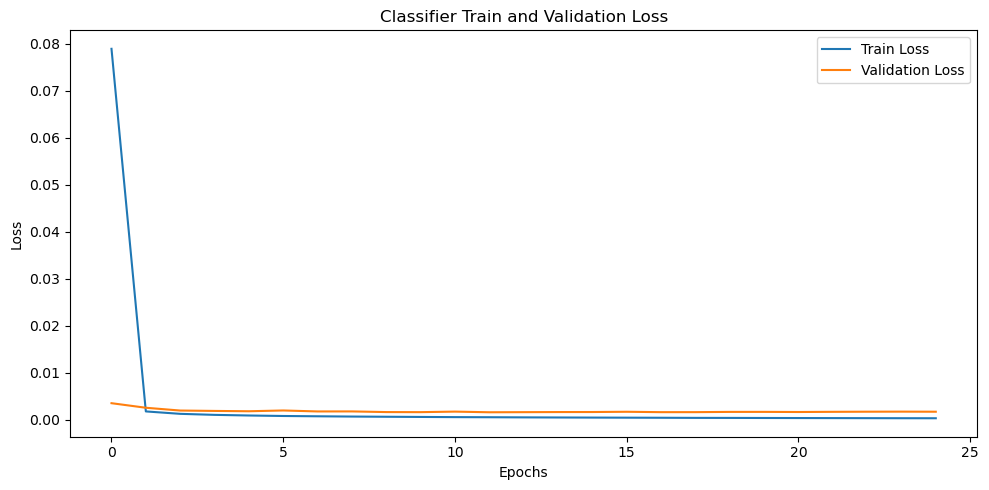

In [29]:
# Plot losses
plt.figure(figsize=(10,5))
plt.plot(classifier_losses[0], label='Train Loss')
plt.plot(classifier_losses[1], label='Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend()
plt.title('Classifier Train and Validation Loss')
plt.tight_layout()
plt.show()

In [30]:
y_hat_test = (classifier.predict(X_val) > 0.5).astype(int)
val_accuracy = accuracy_score(y_val, y_hat_test)
val_precision = precision_score(y_val, y_hat_test)
val_recall = recall_score(y_val, y_hat_test)
val_f1 = f1_score(y_val, y_hat_test)

print(f'Validation set accuracy: {val_accuracy:4f}')
print(f'Validation set precision: {val_precision:4f}')
print(f'Validation set recall: {val_recall:4f}')
print(f'Validation set f1: {val_f1:4f}')

Validation set accuracy: 0.999836
Validation set precision: 0.871795
Validation set recall: 0.971429
Validation set f1: 0.918919


### Classifier Parameters Explanation

For the classifier, I used the following params:
- **sampling scheme**: 
- **hidden layer activation function**: ReLU(). This function works better than sigmoid for the encoder layer since it does not suffer from vanishing gradient issues that are common with sigmoid. Additionally, from my previous experience with neural nets, ReLU() is a faster and more optimal choice for this particular layer.
- **output layer activation function**: Sigmoid(). The network's output layer returns binary values for positive/negative. As such, the sigmoid activation function works well here since it returns values in the range [0,1], which we can threshold to get predictions. ReLU() would have returned results incompatible with our output and that would otherwise have been harder to work with.
- **loss function**: BCE. We are working with a binary classifier, which would be inappropriately suited for MSE.
- **learning rate**: lr of 0.01 was used. This was found through trial error: lr of 1e-3 or lower gave suboptimal results where as lr of 1e-1 similarly gave unstable outputs. lr of 0.01 works the best for this particular architecture, providing a good balance between speed of learning and reasonable reconstruction.
- **batch size**: A batch size of 32 was used for a good balance of speed and performance.
- **epochs**: The model was trained for 100 epochs. This was also found through trial and error: a fewer epoch count returned loss curves that indicated the model could still "learn more" whereas a larger epoch count (100+) took very long and did not yield a significant gain in performance. An epoch count of 100 was a good balance between the two: large enough to offer good performance, but small enough to take only a few seconds to train.